In [36]:
# Import necessary libraries
import kagglehub
from kagglehub import KaggleDatasetAdapter
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import collections
from collections import Counter

# Set the style for the plots
plt.style.use('ggplot')
sns.set(style="whitegrid")

# For reproducibility
np.random.seed(42)

pd.set_option('display.max_colwidth', 200)

## Loading data from Kaggle

In [21]:
# Load data
edges = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jfreyberg/spotify-artist-feature-collaboration-network",
  "edges.csv"
)

nodes = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jfreyberg/spotify-artist-feature-collaboration-network",
  "nodes.csv"
)

/var/folders/xn/vc2qh65j6_17qzhzclh2_ql40000gn/T/ipykernel_2306/2056443041.py:2: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  edges = kagglehub.load_dataset(
/var/folders/xn/vc2qh65j6_17qzhzclh2_ql40000gn/T/ipykernel_2306/2056443041.py:8: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  nodes = kagglehub.load_dataset(


In [38]:
nodes.sort_values('followers', ascending=False).head(20)

,spotify_id,name,followers,popularity,genres,chart_hits
14198,6eUKZXaKkcviH0Ku9w2n3V,Ed Sheeran,102156853.0,90,"['pop', 'uk pop']","['us (52)', 'gb (83)', 'ar (36)', 'au (65)', 'at (59)', 'be (58)', 'bo (29)', 'br (43)', 'bg (60)', 'ca (63)', 'cl (33)', 'co (31)', 'cr (40)', 'cy (44)', 'cz (65)', 'dk (71)', 'do (30)', 'ec (28)..."
17604,66CXWjxzNUsdJxJ2JdwvnR,Ariana Grande,83045090.0,88,"['dance pop', 'pop']","['us (81)', 'gb (69)', 'ar (36)', 'au (70)', 'at (43)', 'be (61)', 'bo (25)', 'br (57)', 'bg (77)', 'ca (80)', 'cl (29)', 'co (34)', 'cr (53)', 'cy (57)', 'cz (41)', 'dk (44)', 'do (51)', 'ec (25)..."
18188,6qqNVTkY8uBg9cP3Jd7DAH,Billie Eilish,68407227.0,88,"['art pop', 'electropop', 'pop']","['us (46)', 'gb (43)', 'ar (23)', 'au (45)', 'at (42)', 'be (43)', 'bo (18)', 'br (23)', 'bg (45)', 'ca (44)', 'cl (17)', 'co (19)', 'cr (26)', 'cy (44)', 'cz (35)', 'dk (42)', 'do (25)', 'ec (18)..."
18726,3TVXtAsR1Inumwj472S9r4,Drake,66852536.0,95,"['canadian hip hop', 'canadian pop', 'hip hop', 'rap', 'toronto rap']","['us (190)', 'gb (163)', 'ar (18)', 'au (148)', 'at (97)', 'be (99)', 'bo (22)', 'br (31)', 'bg (125)', 'ca (179)', 'cl (20)', 'co (24)', 'cr (52)', 'cy (105)', 'cz (55)', 'dk (132)', 'do (116)', ..."
6237,1uNFoZAHBGtllmzznpCI3s,Justin Bieber,65590075.0,90,"['canadian pop', 'pop']","['us (58)', 'gb (51)', 'ar (29)', 'au (54)', 'at (44)', 'be (46)', 'bo (23)', 'br (32)', 'bg (40)', 'ca (62)', 'cl (25)', 'co (25)', 'cr (27)', 'cy (31)', 'cz (39)', 'dk (66)', 'do (32)', 'ec (26)..."
5486,7dGJo4pcD2V6oG8kP0tJRR,Eminem,59184634.0,90,"['detroit hip hop', 'hip hop', 'rap']","['us (78)', 'gb (72)', 'ar (7)', 'au (64)', 'at (61)', 'be (48)', 'bo (8)', 'br (10)', 'bg (73)', 'ca (73)', 'cl (5)', 'co (7)', 'cr (15)', 'cy (62)', 'cz (54)', 'dk (54)', 'do (12)', 'ec (8)', 'e..."
4646,06HL4z0CvFAxyc27GXpf02,Taylor Swift,58554324.0,94,['pop'],"['us (136)', 'gb (115)', 'ar (24)', 'au (110)', 'at (36)', 'be (54)', 'bo (12)', 'br (40)', 'bg (49)', 'ca (121)', 'cl (11)', 'co (16)', 'cr (28)', 'cy (43)', 'cz (28)', 'dk (39)', 'do (14)', 'ec ..."
14707,4YRxDV8wJFPHPTeXepOstw,Arijit Singh,58523986.0,86,"['desi pop', 'filmi', 'modern bollywood']","['in (45)', 'my (5)', 'sg (2)', 'ae (3)']"
11203,4q3ewBCX7sLwd24euuV69X,Bad Bunny,55669387.0,100,"['reggaeton', 'trap latino']","['us (76)', 'gb (1)', 'ar (91)', 'au (2)', 'at (5)', 'be (9)', 'bo (97)', 'br (1)', 'bg (5)', 'ca (15)', 'cl (106)', 'co (98)', 'cr (96)', 'cy (11)', 'cz (2)', 'dk (4)', 'do (110)', 'ec (97)', 'eg..."
17550,3Nrfpe0tUJi4K4DXYWgMUX,BTS,54532917.0,91,"['k-pop', 'k-pop boy group']","['us (55)', 'gb (32)', 'ar (30)', 'au (32)', 'at (30)', 'be (17)', 'bo (54)', 'br (31)', 'bg (77)', 'ca (49)', 'cl (32)', 'co (35)', 'cr (34)', 'cy (34)', 'cz (22)', 'dk (13)', 'do (30)', 'ec (34)..."


In [28]:
edges.head()

,id_0,id_1
0,76M2Ekj8bG8W7X2nbx2CpF,7sfl4Xt5KmfyDs2T3SVSMK
1,0hk4xVujcyOr6USD95wcWb,7Do8se3ZoaVqUt3woqqSrD
2,38jpuy3yt3QIxQ8Fn1HTeJ,4csQIMQm6vI2A2SCVDuM2z
3,6PvcxssrQ0QaJVaBWHD07l,6UCQYrcJ6wab6gnQ89OJFh
4,2R1QrQqWuw3IjoP5dXRFjt,4mk1ScvOUkuQzzCZpT6bc0


In [26]:
# Select Artists with chart hits
selected_nodes = nodes[nodes['chart_hits'].notna()].reset_index(drop=True)

In [34]:
selected_nodes

,spotify_id,name,followers,popularity,genres,chart_hits
0,48WvrUGoijadXXCsGocwM4,Byklubben,1738.0,24,"['nordic house', 'russelater']",['no (3)']
1,4lDiJcOJ2GLCK6p9q5BgfK,Kontra K,1999676.0,72,"['christlicher rap', 'german hip hop']","['at (44)', 'de (111)', 'lu (22)', 'ch (31)', 'vn (1)']"
2,652XIvIBNGg3C0KIGEJWit,Maxim,34596.0,36,[],['de (1)']
3,3dXC1YPbnQPsfHPVkm1ipj,Christopher Martin,249233.0,52,"['dancehall', 'lovers rock', 'modern reggae', 'reggae fusion']","['at (1)', 'de (1)']"
4,74terC9ol9zMo8rfzhSOiG,Jakob Hellman,21193.0,39,"['classic swedish pop', 'norrbotten indie', 'swedish pop']",['se (6)']
...,...,...,...,...,...,...
19636,25FdziPY37yQIRXSk7ZUmS,Allame,382819.0,53,"['turkish hip hop', 'turkish trap']",['tr (18)']
19637,6JVB6uiYxpF2K1PGsPRpWR,Erika Vikman,12630.0,47,"['finnish dance pop', 'finnish pop', 'iskelma']",['fi (6)']
19638,0VlrorDSkEbLK1D6VvMgd2,Rubi,7598.0,44,['german pop'],"['at (1)', 'de (1)']"
19639,4rO00pQq33bIv73QyJdivX,Kabasaki,5657.0,57,['urbano espanol'],['es (1)']


In [41]:
# Select edges for the selected nodes
selected_edges = edges[edges['id_0'].isin(selected_nodes['spotify_id']) & edges['id_1'].isin(selected_nodes['spotify_id'])].reset_index(drop=True)
selected_edges

,id_0,id_1
0,0hk4xVujcyOr6USD95wcWb,7Do8se3ZoaVqUt3woqqSrD
1,0k70gnDBLPirCltbTzoxuM,5FK3qokBQYxr7ZLkr8GVFn
2,1bAftSH8umNcGZ0uyV7LMg,1vqR17Iv8VFdzure1TAXEq
3,21ey6s5hEcTcVKDrF5MWby,7uMh23xWiuR7zsNkuNcm2G
4,4Cmzjffz7uLaESQIWIs9G5,6XvZkxVvGXWhlDFTR6Q4sj
...,...,...
72202,6w5qVRuob9t7rfBj9vQfJl,7oxIi3tF8bOBxAcSixbojj
72203,1yIifIA91WgmfzBcjbQB8i,2JwyRtuXf2l6sTnSnGVIa1
72204,1elUiq4X7pxej6FRlrEzjM,3FlCKtwOEYQQYyGVEbxG2Z
72205,7FnZWGw9lwOr7WzieTKEPR,7mUBMaZW1MXGswaneb0JTT


In [42]:
# Create a graph from the selected edges
G = nx.from_pandas_edgelist(selected_edges, source='id_0', target='id_1')

## Basic Network Properties

In [44]:
# Calculate basic network properties
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Is the graph directed? {G.is_directed()}")

# Check if the graph is connected
print(f"Is the graph connected? {nx.is_connected(G)}")

# Find the number of connected components
num_components = nx.number_connected_components(G)
print(f"Number of connected components: {num_components}")

# Find the largest connected component
largest_cc = max(nx.connected_components(G), key=len)
print(f"Size of the largest connected component: {len(largest_cc)}")

# Create a subgraph of the largest connected component
G_lcc = G.subgraph(largest_cc).copy()
print(f"Largest connected component has {G_lcc.number_of_nodes()} nodes and {G_lcc.number_of_edges()} edges")

Number of nodes: 13866
Number of edges: 72207
Is the graph directed? False
Is the graph connected? False
Number of connected components: 178
Size of the largest connected component: 13450
Largest connected component has 13450 nodes and 71946 edges


## Degree Distribution Analysis

Average degree: 10.41
Median degree: 5
Maximum degree: 253
Minimum degree: 1


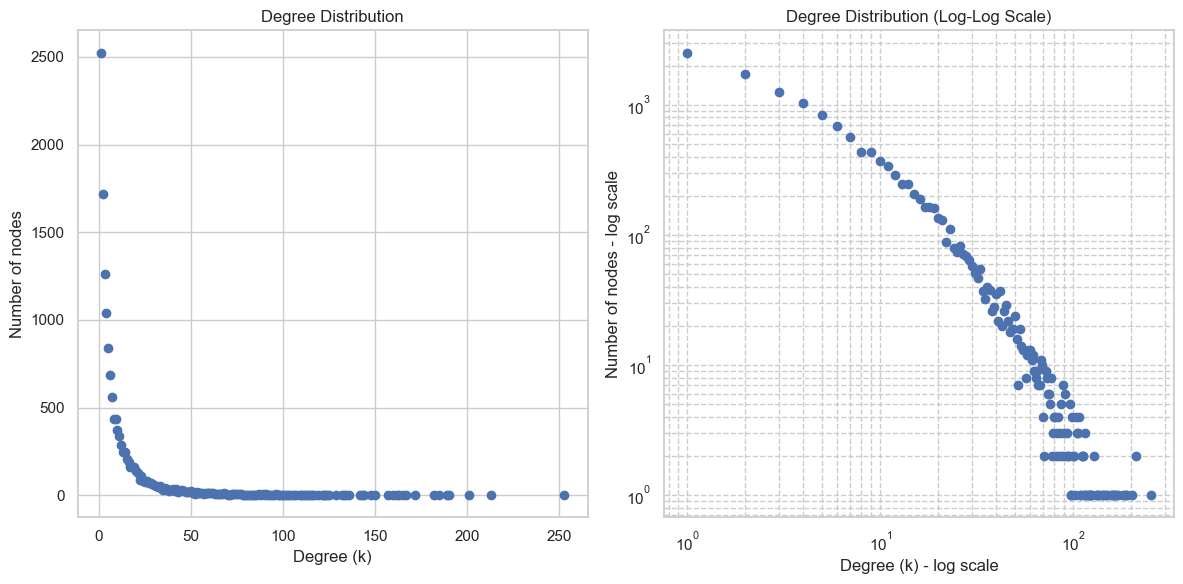

In [45]:
# Calculate the degree distribution
degrees = [G.degree(n) for n in G.nodes()]
degree_counts = Counter(degrees)

# Create a dataframe for easier analysis
degree_df = pd.DataFrame.from_dict(degree_counts, orient='index').reset_index()
degree_df.columns = ['Degree', 'Count']
degree_df = degree_df.sort_values('Degree')

# Calculate degree statistics
avg_degree = np.mean(degrees)
median_degree = np.median(degrees)
max_degree = np.max(degrees)
min_degree = np.min(degrees)

print(f"Average degree: {avg_degree:.2f}")
print(f"Median degree: {median_degree:.0f}")
print(f"Maximum degree: {max_degree}")
print(f"Minimum degree: {min_degree}")

# Plot the degree distribution
plt.figure(figsize=(12, 6))

# Regular plot
plt.subplot(121)
plt.scatter(degree_df['Degree'], degree_df['Count'])
plt.xlabel('Degree (k)')
plt.ylabel('Number of nodes')
plt.title('Degree Distribution')
plt.grid(True)

# Log-log plot to check for power law
plt.subplot(122)
plt.loglog(degree_df['Degree'], degree_df['Count'], 'o')
plt.xlabel('Degree (k) - log scale')
plt.ylabel('Number of nodes - log scale')
plt.title('Degree Distribution (Log-Log Scale)')
plt.grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()

## Path Length Analysis

Average shortest path length: 5.4492
Network diameter: 18


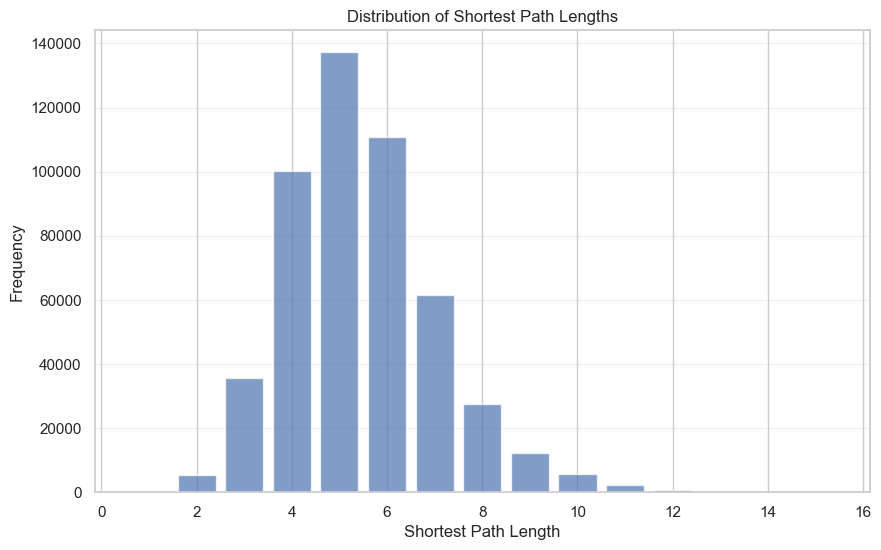

In [46]:
# Calculate the average shortest path length
# Note: We'll use the largest connected component as the full graph might have disconnected parts
avg_shortest_path = nx.average_shortest_path_length(G_lcc)
print(f"Average shortest path length: {avg_shortest_path:.4f}")

# Calculate the diameter (maximum shortest path length)
diameter = nx.diameter(G_lcc)
print(f"Network diameter: {diameter}")

# Calculate the distribution of path lengths
# For large graphs, we'll use a sample of node pairs to estimate
import random
sample_size = min(1000, G_lcc.number_of_nodes())
nodes = list(G_lcc.nodes())
sample_nodes = random.sample(nodes, sample_size)

path_lengths = []
for i in range(sample_size-1):
    for j in range(i+1, sample_size):
        source = sample_nodes[i]
        target = sample_nodes[j]
        path_length = nx.shortest_path_length(G_lcc, source=source, target=target)
        path_lengths.append(path_length)

# Plot the distribution of path lengths
path_counts = Counter(path_lengths)
path_df = pd.DataFrame.from_dict(path_counts, orient='index').reset_index()
path_df.columns = ['Path Length', 'Count']
path_df = path_df.sort_values('Path Length')

plt.figure(figsize=(10, 6))
plt.bar(path_df['Path Length'], path_df['Count'], alpha=0.7)
plt.xlabel('Shortest Path Length')
plt.ylabel('Frequency')
plt.title('Distribution of Shortest Path Lengths')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

## Clustering Analysis

Global clustering coefficient (transitivity): 0.1664
Average local clustering coefficient: 0.1714


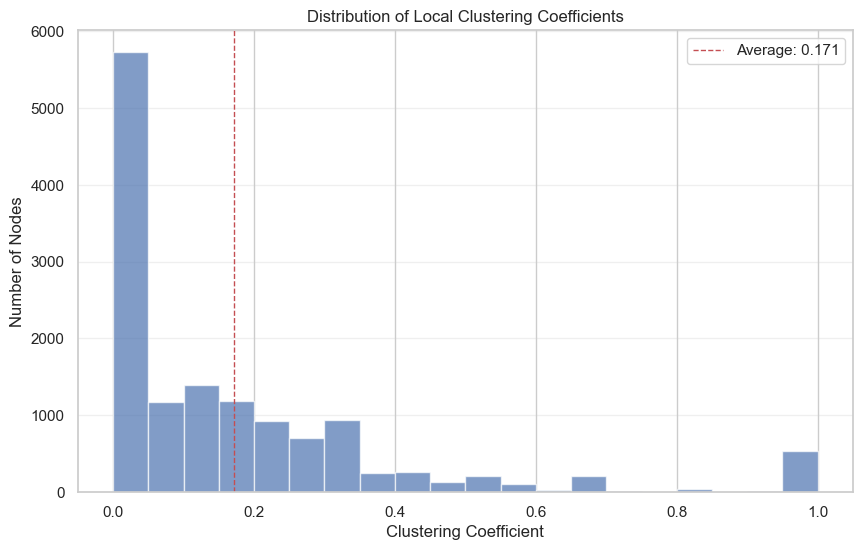

In [47]:
# Calculate the global clustering coefficient (transitivity)
global_clustering = nx.transitivity(G)
print(f"Global clustering coefficient (transitivity): {global_clustering:.4f}")

# Calculate the average local clustering coefficient
avg_local_clustering = nx.average_clustering(G)
print(f"Average local clustering coefficient: {avg_local_clustering:.4f}")

# Calculate local clustering coefficients for each node
clustering_coeffs = nx.clustering(G)

# Create a dataframe for analysis
clustering_df = pd.DataFrame.from_dict(clustering_coeffs, orient='index').reset_index()
clustering_df.columns = ['Node', 'Clustering Coefficient']

# Plot histogram of clustering coefficients
plt.figure(figsize=(10, 6))
plt.hist(clustering_df['Clustering Coefficient'], bins=20, alpha=0.7)
plt.xlabel('Clustering Coefficient')
plt.ylabel('Number of Nodes')
plt.title('Distribution of Local Clustering Coefficients')
plt.grid(True, axis='y', alpha=0.3)
plt.axvline(avg_local_clustering, color='r', linestyle='dashed', linewidth=1, 
            label=f'Average: {avg_local_clustering:.3f}')
plt.legend()
plt.show()

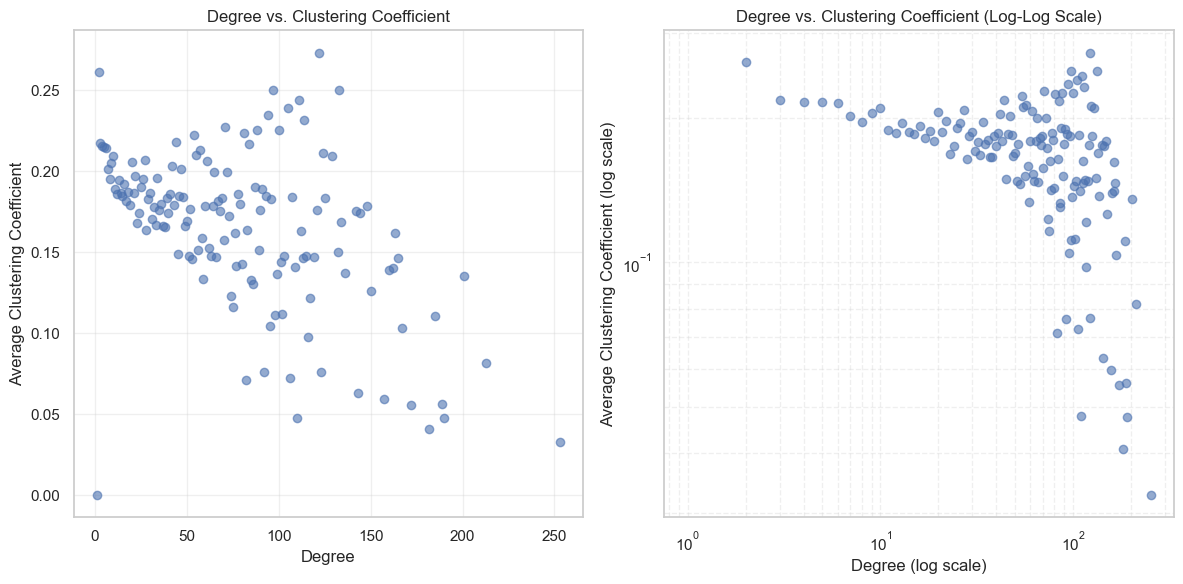

In [48]:
# Analyze the relationship between degree and clustering coefficient
degree_clustering = {}
for node in G.nodes():
    degree = G.degree(node)
    clustering = clustering_coeffs[node]
    if degree in degree_clustering:
        degree_clustering[degree].append(clustering)
    else:
        degree_clustering[degree] = [clustering]

# Calculate average clustering coefficient for each degree
avg_clustering_by_degree = {k: np.mean(v) for k, v in degree_clustering.items()}

# Convert to dataframe
dc_df = pd.DataFrame(list(avg_clustering_by_degree.items()), columns=['Degree', 'Avg Clustering'])
dc_df = dc_df.sort_values('Degree')

# Plot degree vs clustering coefficient
plt.figure(figsize=(12, 6))

# Regular plot
plt.subplot(121)
plt.scatter(dc_df['Degree'], dc_df['Avg Clustering'], alpha=0.6)
plt.xlabel('Degree')
plt.ylabel('Average Clustering Coefficient')
plt.title('Degree vs. Clustering Coefficient')
plt.grid(True, alpha=0.3)

# Log-log plot
plt.subplot(122)
plt.loglog(dc_df['Degree'], dc_df['Avg Clustering'], 'o', alpha=0.6)
plt.xlabel('Degree (log scale)')
plt.ylabel('Average Clustering Coefficient (log scale)')
plt.title('Degree vs. Clustering Coefficient (Log-Log Scale)')
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Centrality Analysis

In [49]:
# For large networks, computing centrality measures can be time-consuming
# We'll work with the largest connected component for this analysis

# Calculate degree centrality
degree_centrality = nx.degree_centrality(G_lcc)

# Calculate betweenness centrality (this might take some time)
print("Computing betweenness centrality (this might take a while)...")
# Use approximate betweenness with sampling for large networks
k = min(1000, G_lcc.number_of_nodes())  # Number of sample nodes
betweenness_centrality = nx.betweenness_centrality(G_lcc, k=k, normalized=True, seed=42)

# Calculate closeness centrality
print("Computing closeness centrality...")
closeness_centrality = nx.closeness_centrality(G_lcc)

# Create a dataframe with centrality measures
centrality_df = pd.DataFrame({
    'Node': list(G_lcc.nodes()),
    'Degree Centrality': [degree_centrality[n] for n in G_lcc.nodes()],
    'Betweenness Centrality': [betweenness_centrality[n] for n in G_lcc.nodes()],
    'Closeness Centrality': [closeness_centrality[n] for n in G_lcc.nodes()]
})

# Display top 20 nodes by different centrality measures
print("\nTop 20 nodes by Degree Centrality:")
print(centrality_df.sort_values('Degree Centrality', ascending=False).head(20))

print("\nTop 20 nodes by Betweenness Centrality:")
print(centrality_df.sort_values('Betweenness Centrality', ascending=False).head(20))

print("\nTop 20 nodes by Closeness Centrality:")
print(centrality_df.sort_values('Closeness Centrality', ascending=False).head(20))

Computing betweenness centrality (this might take a while)...
Computing closeness centrality...

Top 20 nodes by Degree Centrality:
                        Node  Degree Centrality  Betweenness Centrality  \
272   6cEuCEZu7PAE9ZSzLLc2oQ           0.018812                0.055025   
259   7c0XG5cIJTrrAgEC3ULPiq           0.015838                0.007166   
924   7hJcb9fa4alzcOq3EaNPoG           0.015838                0.067542   
17    329e4yvIujISKGKz1BZZbO           0.014945                0.018475   
160   77AiFEVeAVj2ORpC85QVJs           0.014127                0.015065   
329   1Cs0zKBU1kc0i8ypK3B9ai           0.014053                0.018180   
390   6vXTefBL93Dj5IqAWq6OTv           0.013756                0.015246   
734   5fMUXHkw8R8eOP2RNVYEZX           0.013533                0.027047   
341   2o5jDhtHVPhrJdv3cEQ99Z           0.012789                0.017132   
97    1vyhD5VmyZ7KMfW5gqLgo5           0.012417                0.015771   
60    55Aa2cqylxrFIXC767Z865           0.01

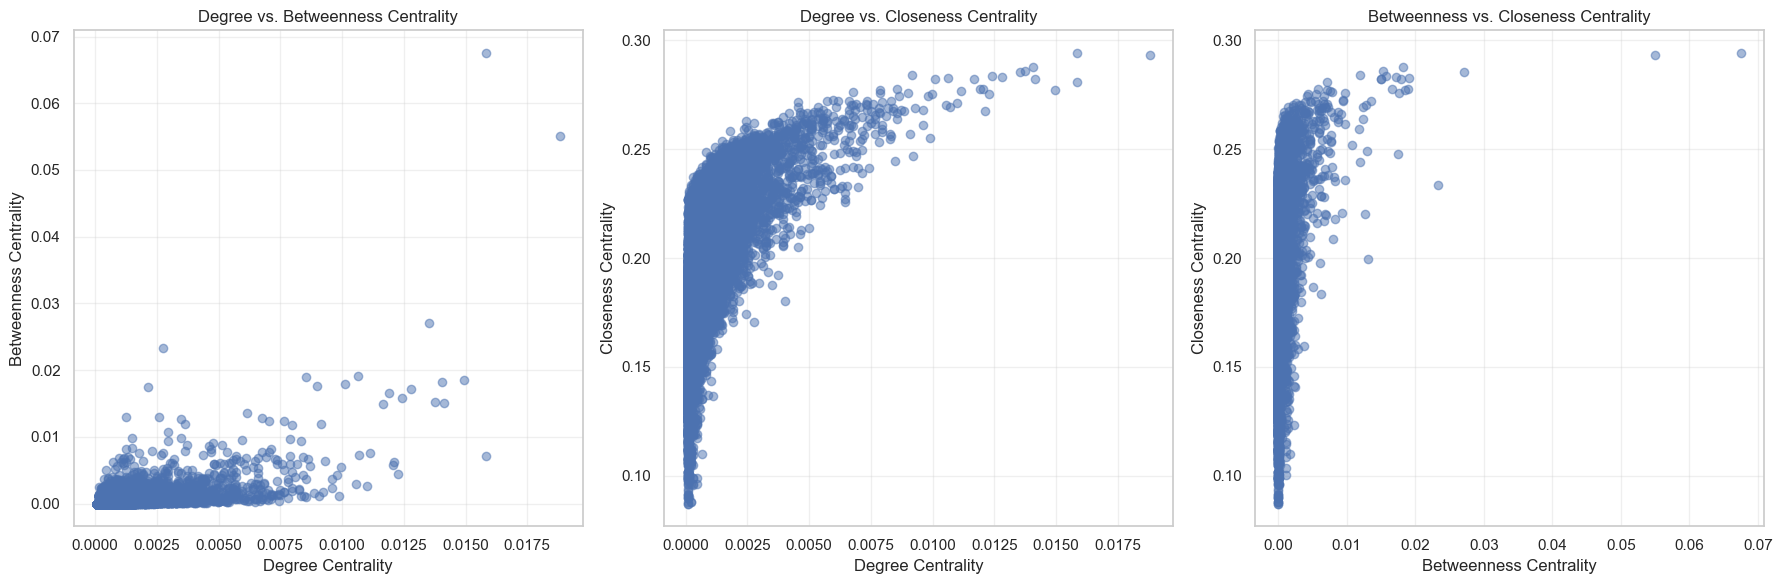

In [50]:
# Compare the different centrality measures
plt.figure(figsize=(18, 6))

# Degree vs Betweenness
plt.subplot(131)
plt.scatter(centrality_df['Degree Centrality'], centrality_df['Betweenness Centrality'], alpha=0.5)
plt.xlabel('Degree Centrality')
plt.ylabel('Betweenness Centrality')
plt.title('Degree vs. Betweenness Centrality')
plt.grid(True, alpha=0.3)

# Degree vs Closeness
plt.subplot(132)
plt.scatter(centrality_df['Degree Centrality'], centrality_df['Closeness Centrality'], alpha=0.5)
plt.xlabel('Degree Centrality')
plt.ylabel('Closeness Centrality')
plt.title('Degree vs. Closeness Centrality')
plt.grid(True, alpha=0.3)

# Betweenness vs Closeness
plt.subplot(133)
plt.scatter(centrality_df['Betweenness Centrality'], centrality_df['Closeness Centrality'], alpha=0.5)
plt.xlabel('Betweenness Centrality')
plt.ylabel('Closeness Centrality')
plt.title('Betweenness vs. Closeness Centrality')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Community Detection

Detecting communities using Louvain algorithm...
Number of communities detected: 34

Top 10 communities by size:
    Community  Size
3           3  1732
2           2  1611
9           9  1160
12         12   883
6           6   658
14         14   563
1           1   535
5           5   471
17         17   433
20         20   403


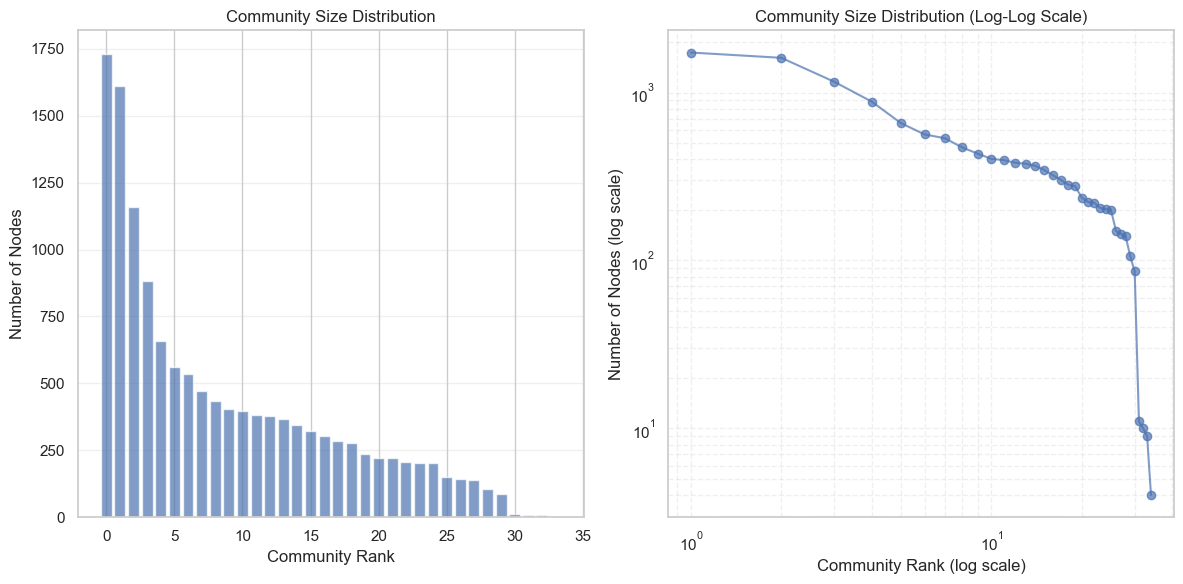

In [51]:
# Community detection using the Louvain algorithm
import community as community_louvain

# Apply the Louvain algorithm
print("Detecting communities using Louvain algorithm...")
partition = community_louvain.best_partition(G_lcc)

# Get the set of communities
communities = set(partition.values())
print(f"Number of communities detected: {len(communities)}")

# Count nodes in each community
community_sizes = Counter(partition.values())
sizes_df = pd.DataFrame.from_dict(community_sizes, orient='index').reset_index()
sizes_df.columns = ['Community', 'Size']
sizes_df = sizes_df.sort_values('Size', ascending=False)

print("\nTop 10 communities by size:")
print(sizes_df.head(10))

# Plot community size distribution
plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.bar(range(len(sizes_df)), sizes_df['Size'], alpha=0.7)
plt.xlabel('Community Rank')
plt.ylabel('Number of Nodes')
plt.title('Community Size Distribution')
plt.grid(True, axis='y', alpha=0.3)

plt.subplot(122)
plt.loglog(range(1, len(sizes_df) + 1), sizes_df['Size'], 'o-', alpha=0.7)
plt.xlabel('Community Rank (log scale)')
plt.ylabel('Number of Nodes (log scale)')
plt.title('Community Size Distribution (Log-Log Scale)')
plt.grid(True, which='both', ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Small World Properties

In [52]:
# Test for small-world properties
# A network is a small-world network if:
# 1. It has a similar average path length to an equivalent random graph
# 2. It has a much higher clustering coefficient than an equivalent random graph

# Create a random graph with the same number of nodes and average degree
n = G_lcc.number_of_nodes()
m = G_lcc.number_of_edges()
p = 2 * m / (n * (n - 1))  # Probability of edge existence
random_G = nx.erdos_renyi_graph(n, p, seed=42)

# Calculate clustering coefficients
clustering_actual = nx.average_clustering(G_lcc)
clustering_random = nx.average_clustering(random_G)

# Calculate average path lengths
path_length_actual = nx.average_shortest_path_length(G_lcc)
path_length_random = nx.average_shortest_path_length(random_G)

print(f"Actual Network - Average Clustering: {clustering_actual:.4f}")
print(f"Random Network - Average Clustering: {clustering_random:.4f}")
print(f"Clustering Ratio (Actual/Random): {clustering_actual/clustering_random:.2f}x")

print(f"\nActual Network - Average Path Length: {path_length_actual:.4f}")
print(f"Random Network - Average Path Length: {path_length_random:.4f}")
print(f"Path Length Ratio (Actual/Random): {path_length_actual/path_length_random:.2f}x")

# Check sigma for small-worldness
sigma = (clustering_actual / clustering_random) / (path_length_actual / path_length_random)
print(f"\nSmall-worldness coefficient (σ): {sigma:.4f}")
print("A network is considered small-world if σ > 1")

Actual Network - Average Clustering: 0.1752
Random Network - Average Clustering: 0.0009
Clustering Ratio (Actual/Random): 204.60x

Actual Network - Average Path Length: 5.4492
Random Network - Average Path Length: 4.2848
Path Length Ratio (Actual/Random): 1.27x

Small-worldness coefficient (σ): 160.8817
A network is considered small-world if σ > 1


## Network Visualization

<Figure size 1200x1200 with 0 Axes>

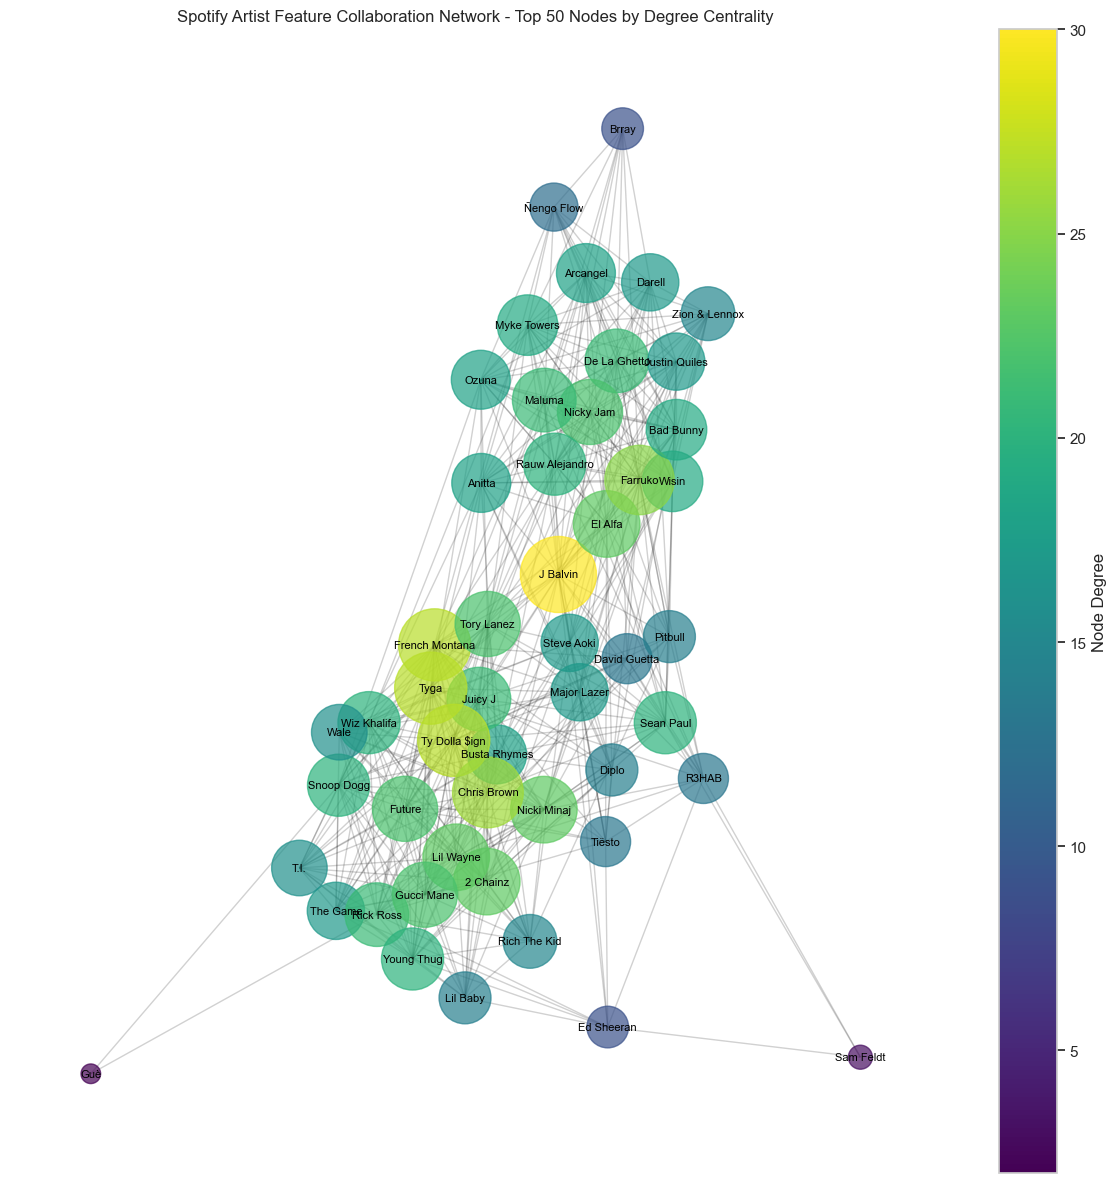

In [72]:
import matplotlib.colors as mcolors

# For large networks, visualization of the entire network might be messy
# We'll visualize a subgraph with the top nodes by degree centrality

# Get top 50 nodes by degree centrality
top_nodes = centrality_df.sort_values('Degree Centrality', ascending=False).head(50)['Node'].tolist()
subgraph = G_lcc.subgraph(top_nodes)

plt.figure(figsize=(12, 12))

# Position nodes using force-directed layout
pos = nx.spring_layout(subgraph, seed=42)

# Get node degrees for sizing
degrees = dict(subgraph.degree())
node_sizes = [v * 100 for v in degrees.values()]

plt.figure(figsize=(12, 12))
ax = plt.gca() # Get the current Axes instance

# Position nodes using force-directed layout
pos = nx.spring_layout(subgraph, seed=42)

# Get node degrees for sizing and coloring
degrees = dict(subgraph.degree())
node_sizes = [v * 100 for v in degrees.values()]
node_colors = list(degrees.values())
cmap = plt.cm.viridis
vmin = min(node_colors)
vmax = max(node_colors)

# Draw the network, explicitly passing the Axes
nodes = nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, alpha=0.7,
                               node_color=node_colors, cmap=cmap, vmin=vmin, vmax=vmax, ax=ax)
nx.draw_networkx_edges(subgraph, pos, alpha=0.2, ax=ax)

# Draw node labels using the Artist Name
id_to_name = dict(zip(selected_nodes['spotify_id'], selected_nodes['name']))
labels = {node: id_to_name.get(node, node) for node in subgraph.nodes()}
nx.draw_networkx_labels(subgraph, pos, labels=labels, font_size=8, font_color='black', ax=ax)


plt.title('Spotify Artist Feature Collaboration Network - Top 50 Nodes by Degree Centrality')

# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([]) # You need this line for the colorbar to work correctly

# Add the colorbar, specifying the mappable and the Axes
plt.colorbar(sm, label='Node Degree', ax=ax)
plt.axis('off')
plt.tight_layout()
plt.show()

## Summary of Network Analysis

In [71]:
# Create a summary of the network analysis
print("Spotify Artist Feature Collaboration Network Analysis Summary")
print("=================================")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Average degree: {avg_degree:.2f}")
print(f"Network density: {nx.density(G):.6f}")
print(f"Global clustering coefficient: {global_clustering:.4f}")
print(f"Average local clustering coefficient: {avg_local_clustering:.4f}")
print(f"Average shortest path length: {path_length_actual:.4f}")
print(f"Network diameter: {diameter}")
print(f"Small-worldness coefficient (σ): {sigma:.4f}")
print(f"Number of connected components: {num_components}")
print(f"Size of the largest connected component: {len(largest_cc)} nodes ({len(largest_cc)/G.number_of_nodes()*100:.2f}% of the network)")
print(f"Number of communities detected: {len(communities)}")

Spotify Artist Feature Collaboration Network Analysis Summary
Number of nodes: 13866
Number of edges: 72207
Average degree: 10.41
Network density: 0.000751
Global clustering coefficient: 0.1664
Average local clustering coefficient: 0.1714
Average shortest path length: 5.4492
Network diameter: 18
Small-worldness coefficient (σ): 160.8817
Number of connected components: 178
Size of the largest connected component: 13450 nodes (97.00% of the network)
Number of communities detected: 34


## Node Classification

In [38]:
# Node classification with GraphSAGE using DGL
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.nn import SAGEConv
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create node features for classification
print("Creating node features...")
node_features = {}
for node in G_lcc.nodes():
    # Node degree
    degree = G_lcc.degree(node)
    
    # Local clustering coefficient
    clustering = nx.clustering(G_lcc, node)
    
    # Centrality measures
    deg_cent = degree_centrality.get(node, 0)
    bet_cent = betweenness_centrality.get(node, 0)
    close_cent = closeness_centrality.get(node, 0)
    
    node_features[node] = [degree, clustering, deg_cent, bet_cent, close_cent]

# Create a synthetic classification task
# Let's classify nodes as "high-influence" if their degree centrality is above the median
median_centrality = np.median([degree_centrality[n] for n in G_lcc.nodes()])
node_labels = {node: 1 if degree_centrality[node] > median_centrality else 0 for node in G_lcc.nodes()}

# Convert to a DGL graph
# Create a node mapping to ensure contiguous node IDs
node_mapping = {node: i for i, node in enumerate(G_lcc.nodes())}
edges_src = []
edges_dst = []

for u, v in G_lcc.edges():
    edges_src.append(node_mapping[u])
    edges_dst.append(node_mapping[v])
    # For undirected graphs, add the reverse edge as well
    edges_src.append(node_mapping[v])
    edges_dst.append(node_mapping[u])

# Create feature and label tensors
features = [node_features[node] for node in G_lcc.nodes()]
labels = [node_labels[node] for node in G_lcc.nodes()]

# Scale features
scaler = StandardScaler()
features = scaler.fit_transform(features)

# Create DGL graph
g = dgl.graph((torch.tensor(edges_src), torch.tensor(edges_dst)))
g.ndata['feat'] = torch.FloatTensor(features)
g.ndata['label'] = torch.LongTensor(labels)

print(f"DGL Graph created: {g}")

# Split nodes for training, validation and testing
n_nodes = g.number_of_nodes()
node_ids = np.arange(n_nodes)
np.random.shuffle(node_ids)

train_idx = node_ids[:int(0.6 * n_nodes)]
val_idx = node_ids[int(0.6 * n_nodes):int(0.8 * n_nodes)]
test_idx = node_ids[int(0.8 * n_nodes):]

train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

g.ndata['train_mask'] = train_mask
g.ndata['val_mask'] = val_mask
g.ndata['test_mask'] = test_mask

# Define the GraphSAGE model
class GraphSAGE(nn.Module):
    def __init__(self, in_feats, h_feats, num_classes):
        super(GraphSAGE, self).__init__()
        self.sage1 = SAGEConv(in_feats, h_feats, 'mean')
        self.sage2 = SAGEConv(h_feats, h_feats, 'mean')
        self.classify = nn.Linear(h_feats, num_classes)
        
    def forward(self, g, h):
        h = self.sage1(g, h)
        h = F.relu(h)
        h = self.sage2(g, h)
        h = F.relu(h)
        return self.classify(h)

# Create the model
in_feats = features.shape[1]
h_feats = 32   # Hidden dimension size
num_classes = 2  # Binary classification

model = GraphSAGE(in_feats, h_feats, num_classes)
model = model.to(device)
g = g.to(device)
features = g.ndata['feat'].to(device)
labels = g.ndata['label'].to(device)
train_mask = g.ndata['train_mask'].to(device)
val_mask = g.ndata['val_mask'].to(device)
test_mask = g.ndata['test_mask'].to(device)

# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
best_val_acc = 0
best_model = None
patience = 20
counter = 0

print("\nTraining GraphSAGE model...")
for epoch in range(200):
    # Training
    model.train()
    logits = model(g, features)
    loss = F.cross_entropy(logits[train_mask], labels[train_mask])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Validation
    model.eval()
    with torch.no_grad():
        logits = model(g, features)
        train_acc = accuracy_score(labels[train_mask].cpu(), logits[train_mask].argmax(dim=1).cpu())
        val_acc = accuracy_score(labels[val_mask].cpu(), logits[val_mask].argmax(dim=1).cpu())
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = {key: value.cpu() for key, value in model.state_dict().items()}
        counter = 0
    else:
        counter += 1
    
    # Early stopping
    if counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

# Load the best model
if best_model is not None:
    model.load_state_dict(best_model)

# Evaluate the model
model.eval()
with torch.no_grad():
    logits = model(g, features)
    test_preds = logits[test_mask].argmax(dim=1).cpu().numpy()
    test_labels = labels[test_mask].cpu().numpy()
    test_acc = accuracy_score(test_labels, test_preds)
    test_f1 = f1_score(test_labels, test_preds, average='macro')

print("\nGraphSAGE Node Classification Results:")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, test_preds))

# Visualize node embeddings
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

model.eval()
with torch.no_grad():
    # Get the output of the second GraphSAGE layer as node embeddings
    h = features
    h = model.sage1(g, h)
    h = F.relu(h)
    embeddings = model.sage2(g, h).cpu().numpy()
    
    # Apply dimensionality reduction
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(embeddings)
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_result = tsne.fit_transform(embeddings)

# Plot node embeddings
plt.figure(figsize=(16, 6))

# Plot PCA results
plt.subplot(121)
all_labels = labels.cpu().numpy()
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=all_labels, cmap='coolwarm', alpha=0.7, s=30)
plt.title('PCA projection of node embeddings')
plt.colorbar(label='Class Label')

# Plot t-SNE results
plt.subplot(122)
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=all_labels, cmap='coolwarm', alpha=0.7, s=30)
plt.title('t-SNE projection of node embeddings')
plt.colorbar(label='Class Label')

plt.tight_layout()
plt.show()

FileNotFoundError: Cannot find DGL C++ graphbolt library at /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/dgl/graphbolt/libgraphbolt_pytorch_2.6.0.dylib

## Link Prediction

In [ ]:
# Link Prediction using DGL
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl
import dgl.function as fn
from dgl.nn import GraphConv
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, classification_report
import random

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("Preparing data for link prediction...")

# Use a smaller subgraph for computational efficiency
top_nodes = list(centrality_df.sort_values('Degree Centrality', ascending=False).head(200)['Node'])
subgraph = G_lcc.subgraph(top_nodes).copy()
print(f"Using a subgraph with {subgraph.number_of_nodes()} nodes and {subgraph.number_of_edges()} edges")

# Create node features
node_features = {}
for node in subgraph.nodes():
    # Node degree
    degree = subgraph.degree(node)
    
    # Local clustering coefficient
    clustering = nx.clustering(subgraph, node)
    
    # Try to get centrality measures
    try:
        deg_cent = nx.degree_centrality(subgraph)[node]
        bet_cent = nx.betweenness_centrality(subgraph)[node]
        close_cent = nx.closeness_centrality(subgraph)[node]
    except:
        deg_cent = bet_cent = close_cent = 0
    
    node_features[node] = [degree, clustering, deg_cent, bet_cent, close_cent]

# Create a node mapping
node_mapping = {node: i for i, node in enumerate(subgraph.nodes())}
reverse_mapping = {i: node for node, i in node_mapping.items()}

# Get all edges and split them
all_edges = list(subgraph.edges())
random.shuffle(all_edges)

# Split edges into train/val/test
n_edges = len(all_edges)
train_edges = all_edges[:int(0.7*n_edges)]
val_edges = all_edges[int(0.7*n_edges):int(0.85*n_edges)]
test_edges = all_edges[int(0.85*n_edges):]

print(f"Train edges: {len(train_edges)}, Val edges: {len(val_edges)}, Test edges: {len(test_edges)}")

# Create a graph with only training edges
train_graph = subgraph.copy()
train_graph.remove_edges_from(val_edges + test_edges)

# Create negative samples for validation and testing
def create_negative_edges(graph, n_samples, existing_edges):
    nodes = list(graph.nodes())
    negative_edges = []
    existing_edge_set = set(existing_edges + [(v, u) for u, v in existing_edges])  # Include both directions
    
    while len(negative_edges) < n_samples:
        u, v = random.sample(nodes, 2)
        if (u, v) not in existing_edge_set and (v, u) not in existing_edge_set and (u, v) not in negative_edges:
            negative_edges.append((u, v))
    
    return negative_edges

val_neg_edges = create_negative_edges(subgraph, len(val_edges), train_edges + test_edges)
test_neg_edges = create_negative_edges(subgraph, len(test_edges), train_edges + val_edges + val_neg_edges)

# Create feature matrix for nodes
features = np.array([node_features[node] for node in subgraph.nodes()])
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Convert to DGL graph
edges_src = []
edges_dst = []

for u, v in train_graph.edges():
    edges_src.append(node_mapping[u])
    edges_dst.append(node_mapping[v])
    # For undirected graphs, add the reverse edge
    edges_src.append(node_mapping[v])
    edges_dst.append(node_mapping[u])

dgl_graph = dgl.graph((torch.tensor(edges_src), torch.tensor(edges_dst)))
dgl_graph.ndata['feat'] = torch.FloatTensor(features_scaled)

# Convert the edge sets for DGL
def convert_edge_sets(edge_list, node_mapping):
    src = [node_mapping[u] for u, v in edge_list]
    dst = [node_mapping[v] for u, v in edge_list]
    return torch.tensor(src), torch.tensor(dst)

val_pos_src, val_pos_dst = convert_edge_sets(val_edges, node_mapping)
val_neg_src, val_neg_dst = convert_edge_sets(val_neg_edges, node_mapping)
test_pos_src, test_pos_dst = convert_edge_sets(test_edges, node_mapping)
test_neg_src, test_neg_dst = convert_edge_sets(test_neg_edges, node_mapping)

# Define the Link Prediction model using GraphSAGE
class LinkPrediction(nn.Module):
    def __init__(self, in_feats, h_feats):
        super(LinkPrediction, self).__init__()
        self.conv1 = GraphConv(in_feats, h_feats)
        self.conv2 = GraphConv(h_feats, h_feats)
        self.predict = nn.Sequential(
            nn.Linear(h_feats * 2, h_feats),
            nn.ReLU(),
            nn.Linear(h_feats, 1)
        )
    
    def forward(self, g, h):
        # Get node embeddings
        h = F.relu(self.conv1(g, h))
        h = self.conv2(g, h)
        return h
    
    def predict_link(self, h, src, dst):
        # Get embeddings for source and destination nodes
        h_src = h[src]
        h_dst = h[dst]
        # Concatenate embeddings and predict link probability
        h_concat = torch.cat([h_src, h_dst], dim=1)
        return torch.sigmoid(self.predict(h_concat)).squeeze()

# Create the model
in_feats = features_scaled.shape[1]
h_feats = 32  # Hidden dimension size
model = LinkPrediction(in_feats, h_feats)

# Move everything to device
model = model.to(device)
dgl_graph = dgl_graph.to(device)
features = dgl_graph.ndata['feat'].to(device)
val_pos_src = val_pos_src.to(device)
val_pos_dst = val_pos_dst.to(device)
val_neg_src = val_neg_src.to(device)
val_neg_dst = val_neg_dst.to(device)
test_pos_src = test_pos_src.to(device)
test_pos_dst = test_pos_dst.to(device)
test_neg_src = test_neg_src.to(device)
test_neg_dst = test_neg_dst.to(device)

# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Define the loss function
loss_fn = nn.BCELoss()

# Training loop
best_val_auc = 0
best_model = None
patience = 20
counter = 0

print("\nTraining Link Prediction model...")
for epoch in range(200):
    model.train()
    
    # Forward pass
    h = model(dgl_graph, features)
    
    # Positive and negative samples for this epoch
    # Sample edges from training graph
    train_pos_src, train_pos_dst = dgl_graph.edges()
    # Use the sampled edges as positive samples, sample same number of negatives
    n_edges_to_sample = min(len(train_pos_src), 1000)  # Limit batch size
    idx = torch.randperm(len(train_pos_src))[:n_edges_to_sample]
    train_pos_src, train_pos_dst = train_pos_src[idx], train_pos_dst[idx]
    
    # Create negative samples
    train_neg_src = train_pos_src
    train_neg_dst = torch.randint(0, dgl_graph.number_of_nodes(), (n_edges_to_sample,), device=device)
    
    # Filter out existing edges from negative samples
    edge_set = set(zip(train_pos_src.cpu().numpy(), train_pos_dst.cpu().numpy()))
    neg_edges = []
    for i in range(len(train_neg_src)):
        src, dst = train_neg_src[i].item(), train_neg_dst[i].item()
        if (src, dst) not in edge_set and src != dst:
            neg_edges.append(i)
    
    train_neg_src = train_neg_src[neg_edges]
    train_neg_dst = train_neg_dst[neg_edges]
    
    # Make sure we have same number of positive and negative samples
    min_size = min(len(train_pos_src), len(train_neg_src))
    train_pos_src, train_pos_dst = train_pos_src[:min_size], train_pos_dst[:min_size]
    train_neg_src, train_neg_dst = train_neg_src[:min_size], train_neg_dst[:min_size]
    
    # Predict on positive and negative samples
    pos_score = model.predict_link(h, train_pos_src, train_pos_dst)
    neg_score = model.predict_link(h, train_neg_src, train_neg_dst)
    
    # Compute loss
    pos_loss = loss_fn(pos_score, torch.ones_like(pos_score))
    neg_loss = loss_fn(neg_score, torch.zeros_like(neg_score))
    loss = pos_loss + neg_loss
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Validation
    model.eval()
    with torch.no_grad():
        h = model(dgl_graph, features)
        val_pos_score = model.predict_link(h, val_pos_src, val_pos_dst)
        val_neg_score = model.predict_link(h, val_neg_src, val_neg_dst)
        
        # Calculate validation AUC
        val_labels = torch.cat([torch.ones_like(val_pos_score), torch.zeros_like(val_neg_score)]).cpu().numpy()
        val_preds = torch.cat([val_pos_score, val_neg_score]).cpu().numpy()
        val_auc = roc_auc_score(val_labels, val_preds)
        
        # Save best model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model = {key: value.cpu() for key, value in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
        
        # Early stopping
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 10 == 0:
        train_auc = roc_auc_score(
            torch.cat([torch.ones_like(pos_score), torch.zeros_like(neg_score)]).cpu().numpy(),
            torch.cat([pos_score, neg_score]).detach().cpu().numpy()
        )
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f}")

# Load the best model
if best_model is not None:
    model.load_state_dict(best_model)
    model = model.to(device)

# Evaluate on test set
model.eval()
with torch.no_grad():
    h = model(dgl_graph, features)
    test_pos_score = model.predict_link(h, test_pos_src, test_pos_dst)
    test_neg_score = model.predict_link(h, test_neg_src, test_neg_dst)
    
    # Calculate test metrics
    test_labels = torch.cat([torch.ones_like(test_pos_score), torch.zeros_like(test_neg_score)]).cpu().numpy()
    test_preds = torch.cat([test_pos_score, test_neg_score]).cpu().numpy()
    test_auc = roc_auc_score(test_labels, test_preds)
    
    # Binary predictions for other metrics
    test_binary_preds = (test_preds > 0.5).astype(int)
    test_acc = accuracy_score(test_labels, test_binary_preds)

print("\nDGL Link Prediction Results:")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, test_binary_preds))

# Plot ROC curve
fpr, tpr, _ = roc_curve(test_labels, test_preds)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {test_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - DGL Link Prediction')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Visualize node embeddings colored by their linking properties
from sklearn.decomposition import PCA

# Get node embeddings
node_embeddings = h.cpu().numpy()

# Reduce to 2D for visualization
pca = PCA(n_components=2)
embed_2d = pca.fit_transform(node_embeddings)

# Plot the embeddings
plt.figure(figsize=(10, 8))
plt.scatter(embed_2d[:, 0], embed_2d[:, 1], alpha=0.7)

# Draw a few example edges
n_examples = min(20, len(test_pos_src))  # Show up to 20 examples
for i in range(n_examples):
    src, dst = test_pos_src[i].item(), test_pos_dst[i].item()
    plt.plot([embed_2d[src, 0], embed_2d[dst, 0]], 
             [embed_2d[src, 1], embed_2d[dst, 1]], 'r-', alpha=0.5)

plt.title('Node Embeddings with Selected Positive Links')
plt.xlabel('PCA Dimension 1')
plt.ylabel('PCA Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()